# 🧠 EEG BITalino — Filtrado (Pasa banda 0.5–40 Hz + Notch 50/60 Hz)
**GUÍA N° 4 — Universidad Peruana Cayetano Heredia**

Este notebook toma la configuración original hasta la **configuración de rutas**
y aplica a las señales:

- **Filtro pasa banda:** 0.5 – 40 Hz (Butterworth, orden 4, `filtfilt`)
- **Filtro notch:** 50 Hz y 60 Hz (`iirnotch`)

> ⚠️ **Nota técnica:** el BITalino EEG muestrea a **FS = 100 Hz**, por lo que la
> frecuencia de Nyquist es **50 Hz**. Un notch en 50 Hz cae justo en el límite
> de Nyquist y uno en 60 Hz está por encima de él, así que **no es posible
> filtrarlos realmente** con esta tasa de muestreo. El código valida esto y
> te avisará en pantalla en vez de fallar o de "filtrar" algo inexistente.


---
## 1. Instalación e importación de librerías

In [ ]:
!pip install scipy numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
import os, json


---
## 2. Parámetros de adquisición

In [ ]:
FS       = 100      # Hz (confirmado del header OpenSignals)
VCC      = 3.3
ADC_BITS = 10
GAIN_EEG = 40000    # ganancia interna BITalino EEG

print('FS =', FS, 'Hz | Nyquist =', FS/2, 'Hz')


FS = 100 Hz | Nyquist = 50.0 Hz


---
## 3. Función de carga de archivos BITalino

In [ ]:
def load_bitalino(filepath):
    raw_vals, fs_file = [], FS
    with open(filepath, 'r') as f:
        for line in f:
            s = line.rstrip()
            if s.startswith('# {'):
                try:
                    meta = json.loads(s[2:])
                    key  = list(meta.keys())[0]
                    fs_file = int(meta[key].get('sampling rate', FS))
                except Exception:
                    pass
            elif s.startswith('#'):
                continue
            else:
                p = s.split('\t')
                if len(p) >= 6:
                    try: raw_vals.append(int(p[5]))
                    except ValueError: pass
    raw = np.array(raw_vals, dtype=float)
    uv  = ((raw / 2**ADC_BITS) - 0.5) * VCC / GAIN_EEG * 1e6
    t   = np.arange(len(uv)) / fs_file
    return t, uv, fs_file

---
## 4. Configuración de rutas

In [ ]:
# archivos de drive
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/EEG/'


def fp(n): return os.path.join(BASE, f'eeg_{n}.txt')

print('Estado de archivos:')
for i in range(1, 7):
    s = '✅' if os.path.exists(fp(i)) else 'NO ENCONTRADO'
    print(f'  eeg_{i}.txt  {s}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Estado de archivos:
  eeg_1.txt  ✅
  eeg_2.txt  ✅
  eeg_3.txt  ✅
  eeg_4.txt  ✅
  eeg_5.txt  ✅
  eeg_6.txt  ✅


---
## 5. Filtros: pasa banda (0.5–40 Hz) y notch (50/60 Hz)

In [ ]:
def bandpass_filter(sig, lo=0.5, hi=40.0, fs=FS, order=4):
    nyq = fs / 2.0
    hi_eff = min(hi, nyq - 0.5)   # evita salirse de Nyquist
    if hi_eff != hi:
        print(f'Límite superior ajustado de {hi} Hz a {hi_eff:.2f} Hz (Nyquist = {nyq} Hz)')
    b, a = butter(order, [lo/nyq, hi_eff/nyq], btype='band')
    return filtfilt(b, a, sig)


def notch_filter(sig, freq, Q=30, fs=FS):
    if freq >= fs/2: return sig
    b, a = iirnotch(freq/(fs/2), Q)
    return filtfilt(b, a, sig)


def apply_filters(sig, fs=FS, notch_freqs=(50.0, 60.0)):
    out = bandpass_filter(sig, lo=0.5, hi=40.0, fs=fs)
    for f0 in notch_freqs:
        out = notch_filter(out, f0, fs=fs)
    return out

print('✅ Filtros definidos (pasa banda 0.5–40 Hz + notch 50/60 Hz)')


✅ Filtros definidos (pasa banda 0.5–40 Hz + notch 50/60 Hz)


---
## 6. Aplicación del filtrado a cada archivo EEG

In [ ]:
ARCHIVOS = {
    1: 'Basal 1 (ojos cerrados)',
    2: 'Apertura de ojos',
    3: 'Basal 2',
    4: 'Artefactos',
    5: 'Basal 3',
    6: 'Libre (música)',
}

signals = {}   # guarda t, raw y filtrado por archivo

for n, label in ARCHIVOS.items():
    filepath = fp(n)
    if not os.path.exists(filepath):
        print(f'No encontrado: {filepath}')
        continue

    print(f'\n{"="*60}\n  eeg_{n}.txt — {label}\n{"="*60}')
    t, raw, fs = load_bitalino(filepath)
    flt = apply_filters(raw, fs=fs)

    signals[n] = dict(t=t, raw=raw, flt=flt, fs=fs, label=label)
    print(f'  Duración: {t[-1]:.1f}s | Muestras: {len(t)} | FS: {fs} Hz')

print('\n Filtrado aplicado a todas las señales disponibles')



  eeg_1.txt — Basal 1 (ojos cerrados)
  Duración: 60.6s | Muestras: 6060 | FS: 100 Hz

  eeg_2.txt — Apertura de ojos
  Duración: 60.6s | Muestras: 6060 | FS: 100 Hz

  eeg_3.txt — Basal 2
  Duración: 30.7s | Muestras: 3075 | FS: 100 Hz

  eeg_4.txt — Artefactos
  Duración: 60.6s | Muestras: 6060 | FS: 100 Hz

  eeg_5.txt — Basal 3
  Duración: 30.9s | Muestras: 3090 | FS: 100 Hz

  eeg_6.txt — Libre (música)
  Duración: 118.8s | Muestras: 11880 | FS: 100 Hz

 Filtrado aplicado a todas las señales disponibles


---
## 7. Visualización: señal cruda vs. filtrada

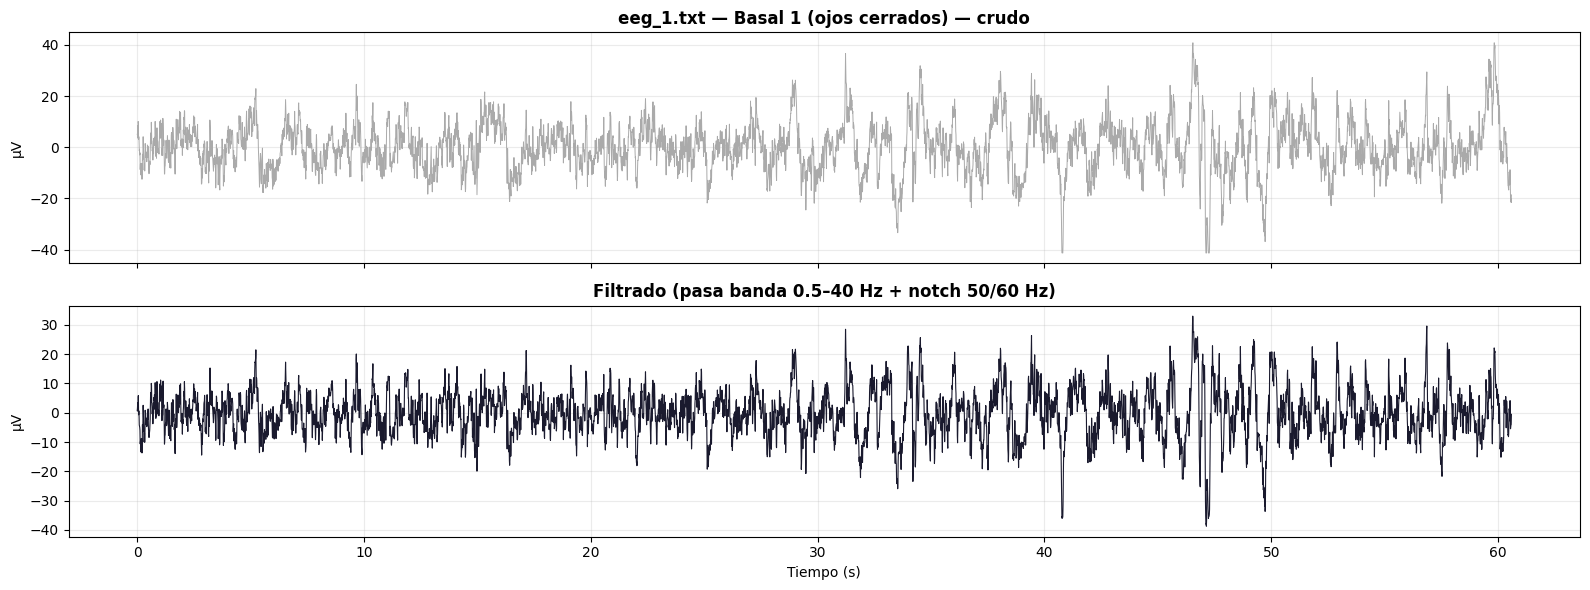

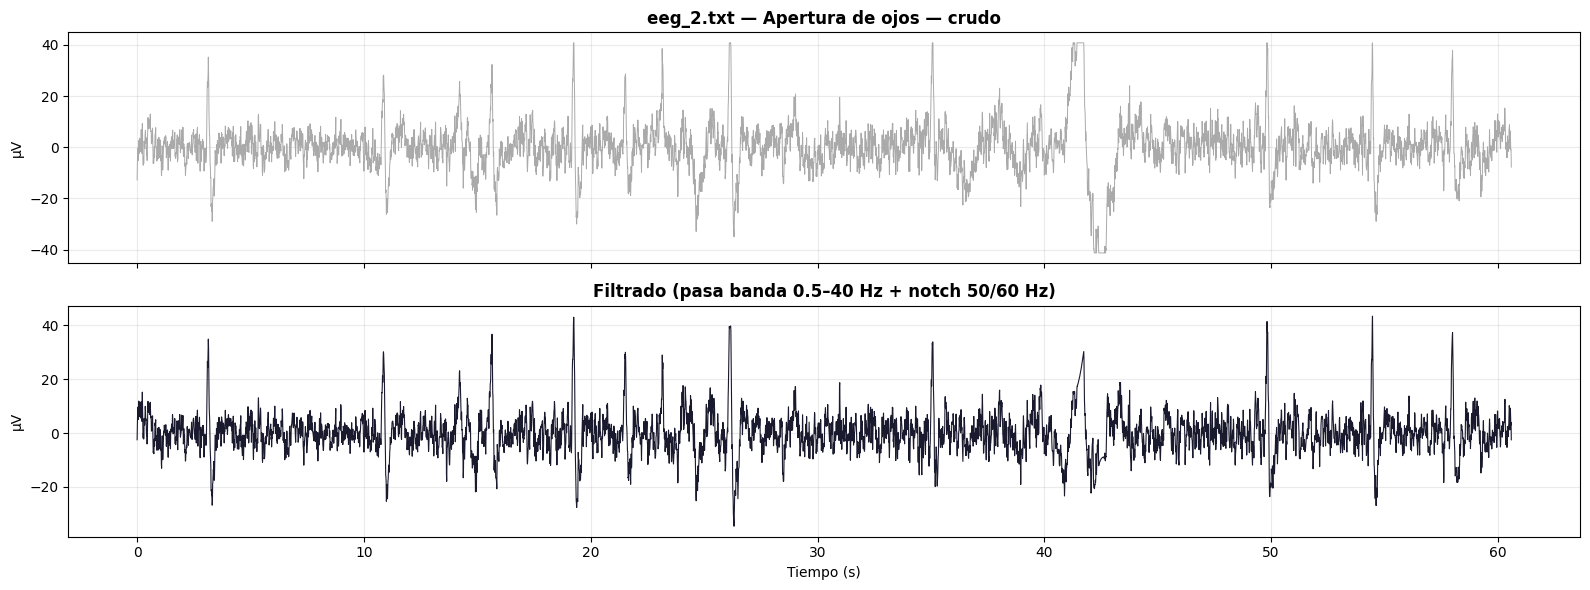

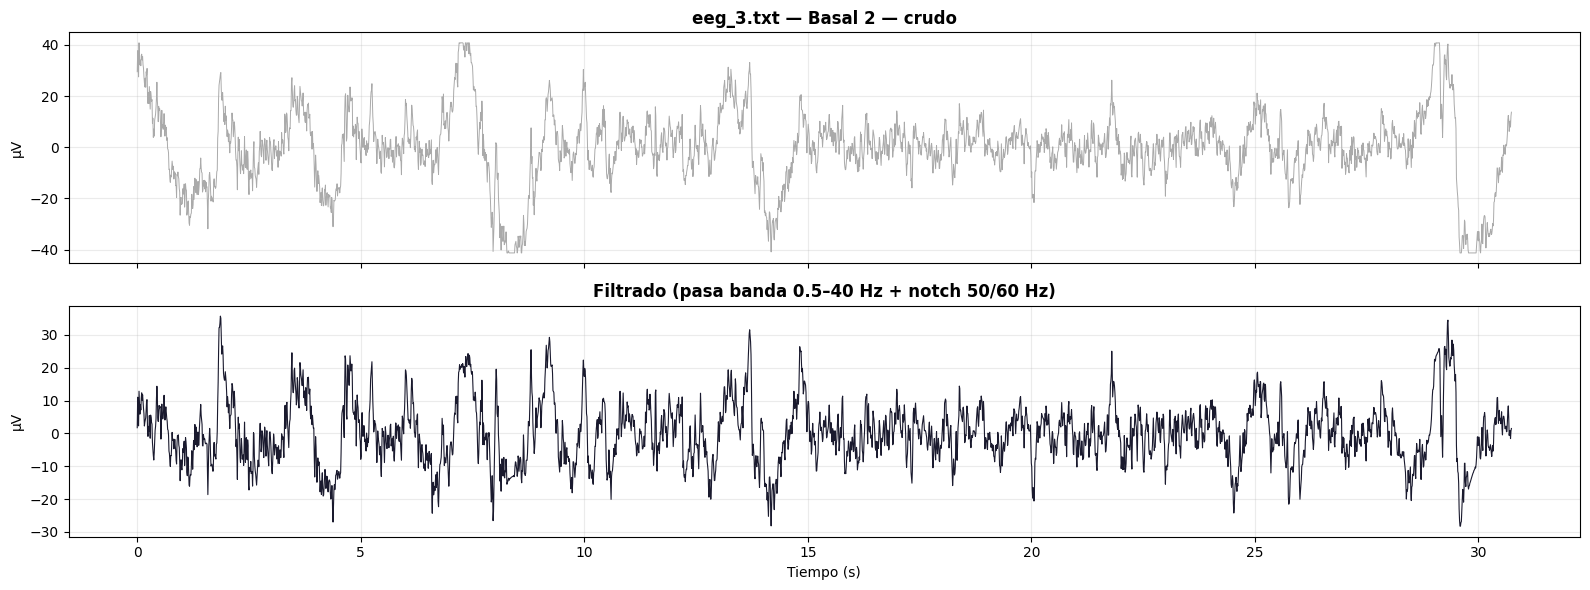

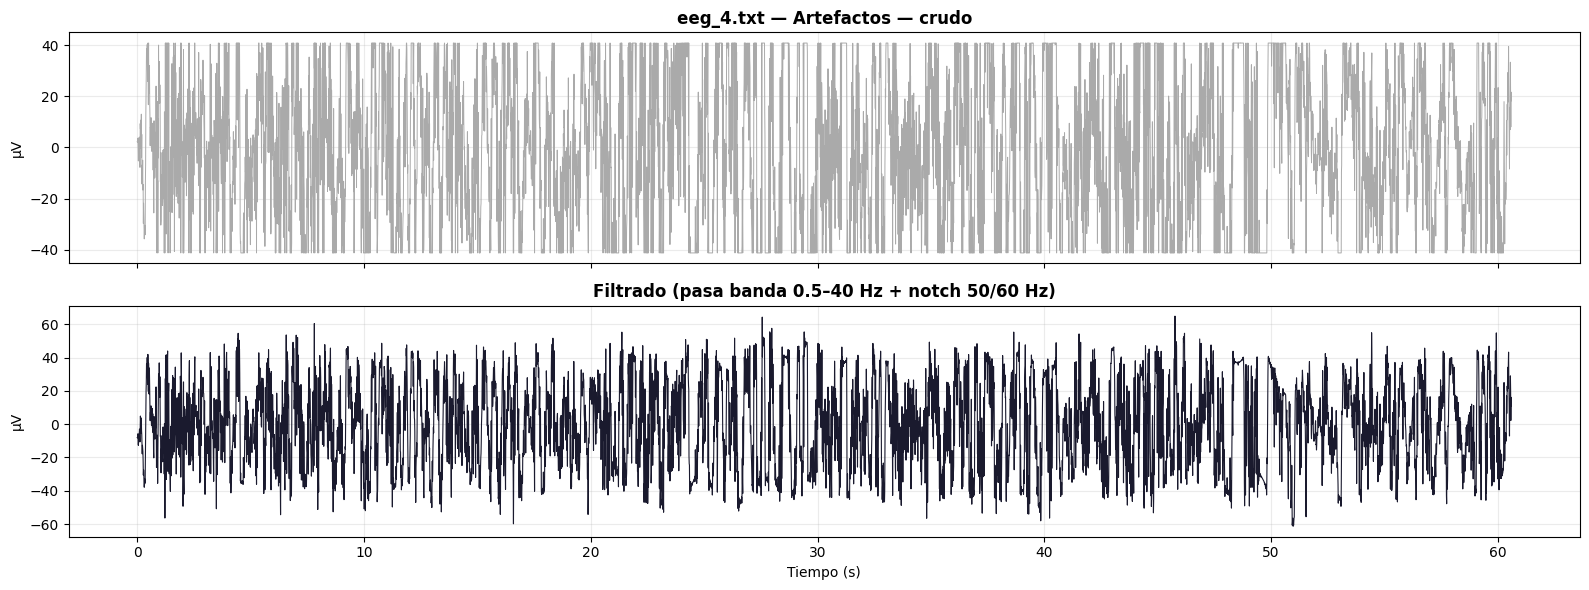

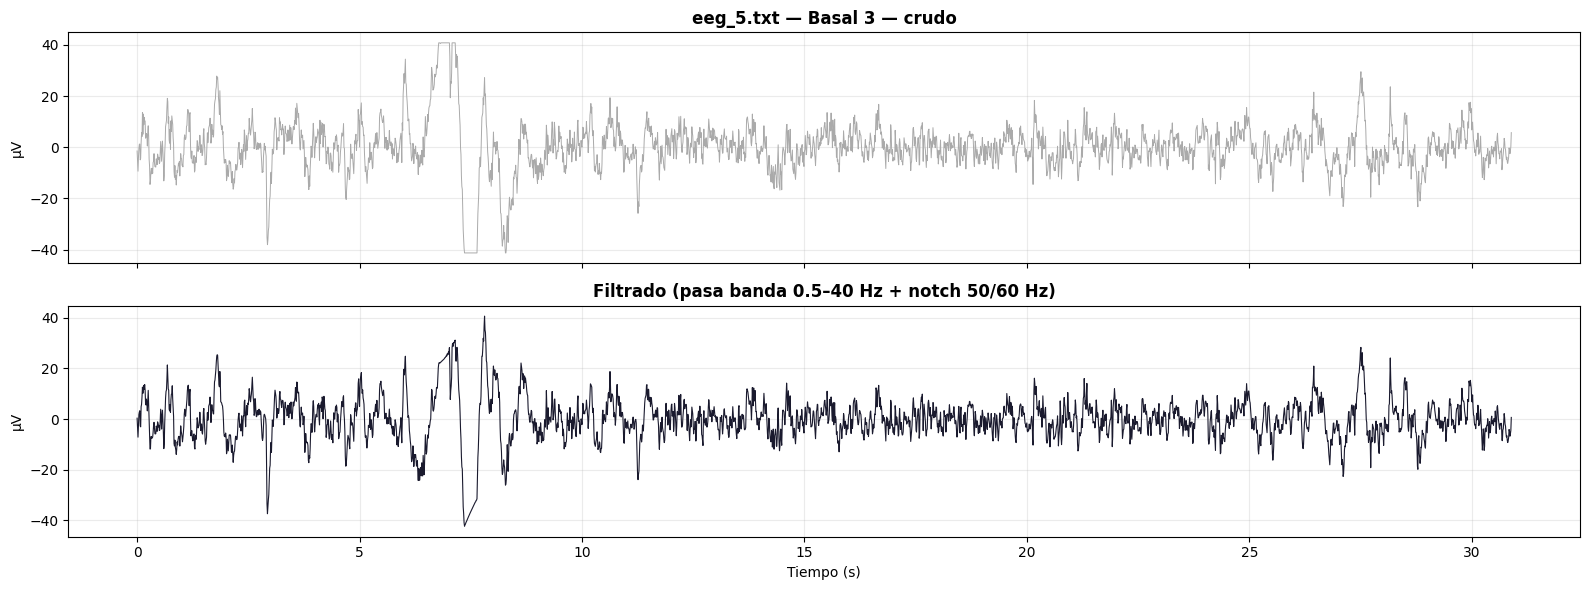

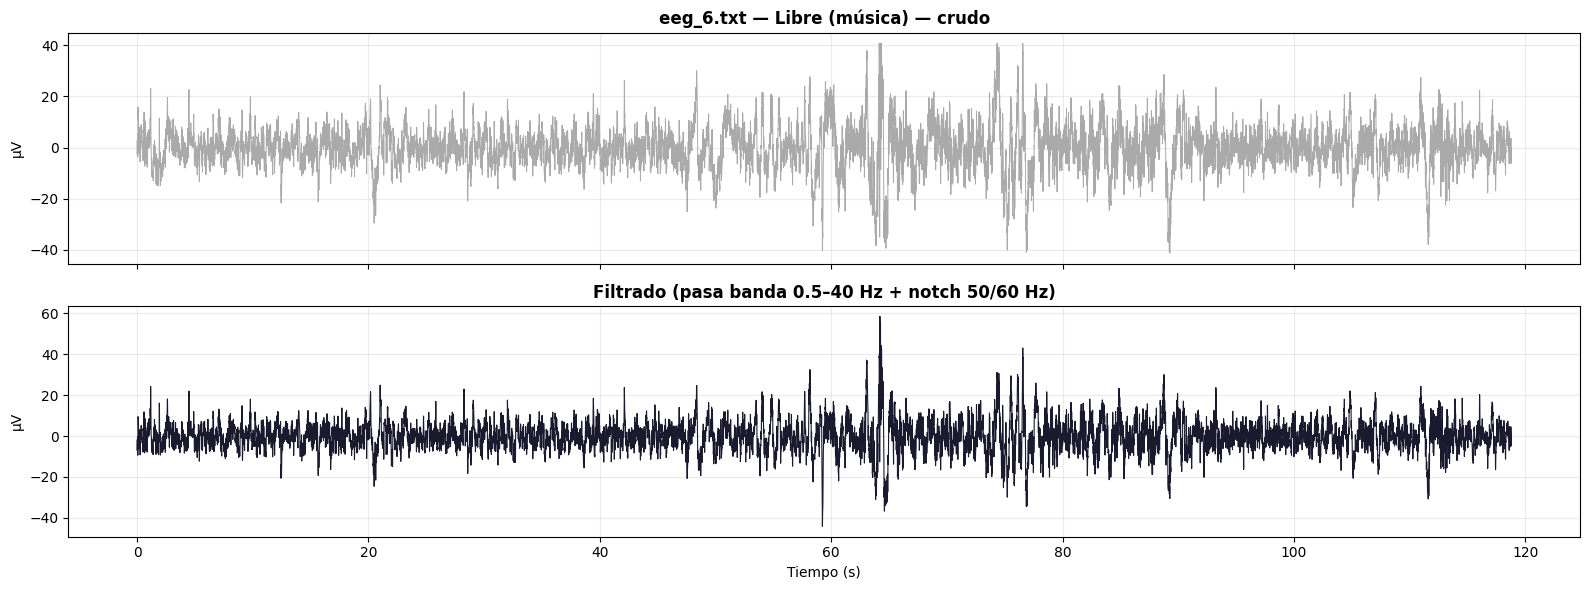

In [ ]:
for n, d in signals.items():
    fig, ax = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
    ax[0].plot(d['t'], d['raw'], color='#aaa', lw=0.7)
    ax[0].set_ylabel('µV'); ax[0].set_title(f"eeg_{n}.txt — {d['label']} — crudo", fontweight='bold')
    ax[0].grid(alpha=0.25)

    ax[1].plot(d['t'], d['flt'], color='#1a1a2e', lw=0.8)
    ax[1].set_xlabel('Tiempo (s)'); ax[1].set_ylabel('µV')
    ax[1].set_title('Filtrado (pasa banda 0.5–40 Hz + notch 50/60 Hz)', fontweight='bold')
    ax[1].grid(alpha=0.25)

    plt.tight_layout(); plt.show()


# 8. ICA

In [ ]:
!pip install EMD-signal -q

from PyEMD import EMD
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.


In [ ]:
def emd_ica_decompose(sig, max_imfs=8, random_state=97):
    """Descompone 'sig' en IMFs (EMD) y aplica ICA tratando cada IMF
    como un pseudo-canal. Retorna (imfs, S, ica).
      imfs : (n_imfs, n_samples)      -- modos empíricos
      S    : (n_samples, n_imfs)      -- componentes independientes
      ica  : objeto FastICA ajustado
    """
    emd = EMD()
    imfs = emd.emd(sig, max_imf=max_imfs)
    n_imfs = imfs.shape[0]
    if n_imfs < 2:
        raise ValueError(f'Solo se obtuvieron {n_imfs} IMF(s); se necesitan al menos 2 para ICA.')

    ica = FastICA(n_components=n_imfs, random_state=random_state, max_iter=1000)
    X = imfs.T                     # (n_samples, n_imfs)
    S = ica.fit_transform(X)       # componentes independientes
    return imfs, S, ica


def reconstruct_clean(S, ica, exclude):
    """Pone a cero los componentes en 'exclude' y reconstruye la señal
    sumando los IMFs limpios."""
    S_clean = S.copy()
    S_clean[:, exclude] = 0.0
    X_clean = ica.inverse_transform(S_clean)   # (n_samples, n_imfs)
    return X_clean.sum(axis=1)                 # señal reconstruida (1 canal)


Procesando eeg_1.txt...
Componentes a excluir: [5]


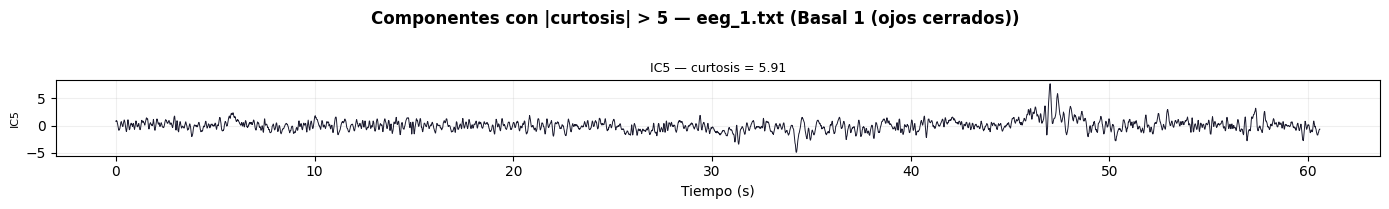


Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:   4.070
  IC1:  -1.104
  IC2:   3.635
  IC3:   1.594
  IC4:   2.463
  IC5:   5.914  ⚠️ candidato a artefacto
  IC6:   1.096
  IC7:   1.931
  IC8:   0.662

Procesando eeg_2.txt...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Componentes a excluir: [0, 5, 6, 7]


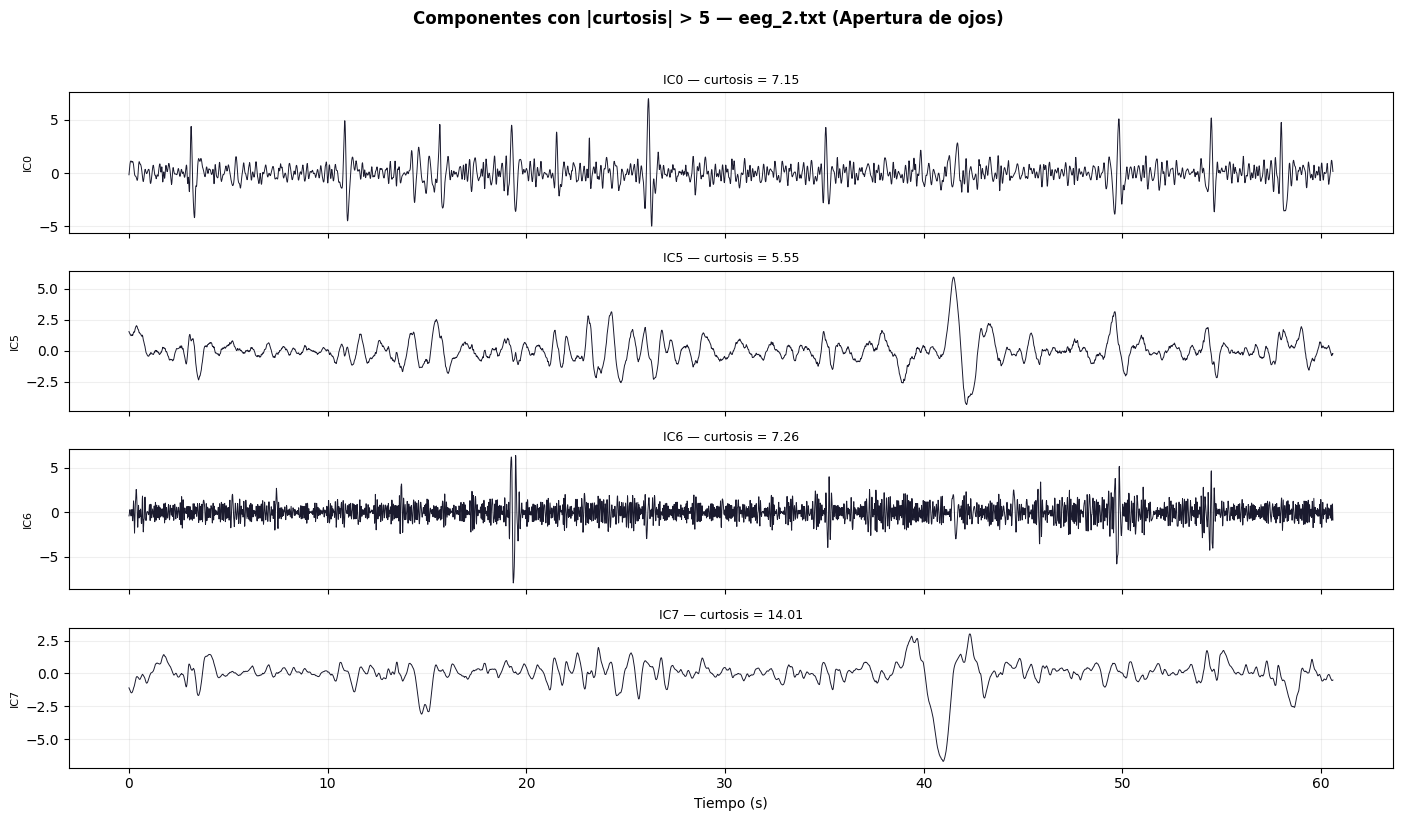


Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:   7.146  ⚠️ candidato a artefacto
  IC1:  -0.228
  IC2:   3.610
  IC3:   0.276
  IC4:  -0.499
  IC5:   5.548  ⚠️ candidato a artefacto
  IC6:   7.258  ⚠️ candidato a artefacto
  IC7:  14.014  ⚠️ candidato a artefacto
  IC8:  -0.563

Procesando eeg_3.txt...
Componentes a excluir: []
No hay componentes con |curtosis| > 5.

Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:   0.173
  IC1:   1.283
  IC2:   2.298
  IC3:   1.903
  IC4:   0.737
  IC5:   3.345
  IC6:   1.859
  IC7:   1.725
  IC8:   2.460

Procesando eeg_4.txt...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Componentes a excluir: []
No hay componentes con |curtosis| > 5.

Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:  -0.687
  IC1:   0.999
  IC2:   0.773
  IC3:   1.018
  IC4:   2.786
  IC5:   0.897
  IC6:   1.314
  IC7:   1.659
  IC8:   0.393

Procesando eeg_5.txt...
Componentes a excluir: [0, 2, 7, 8]


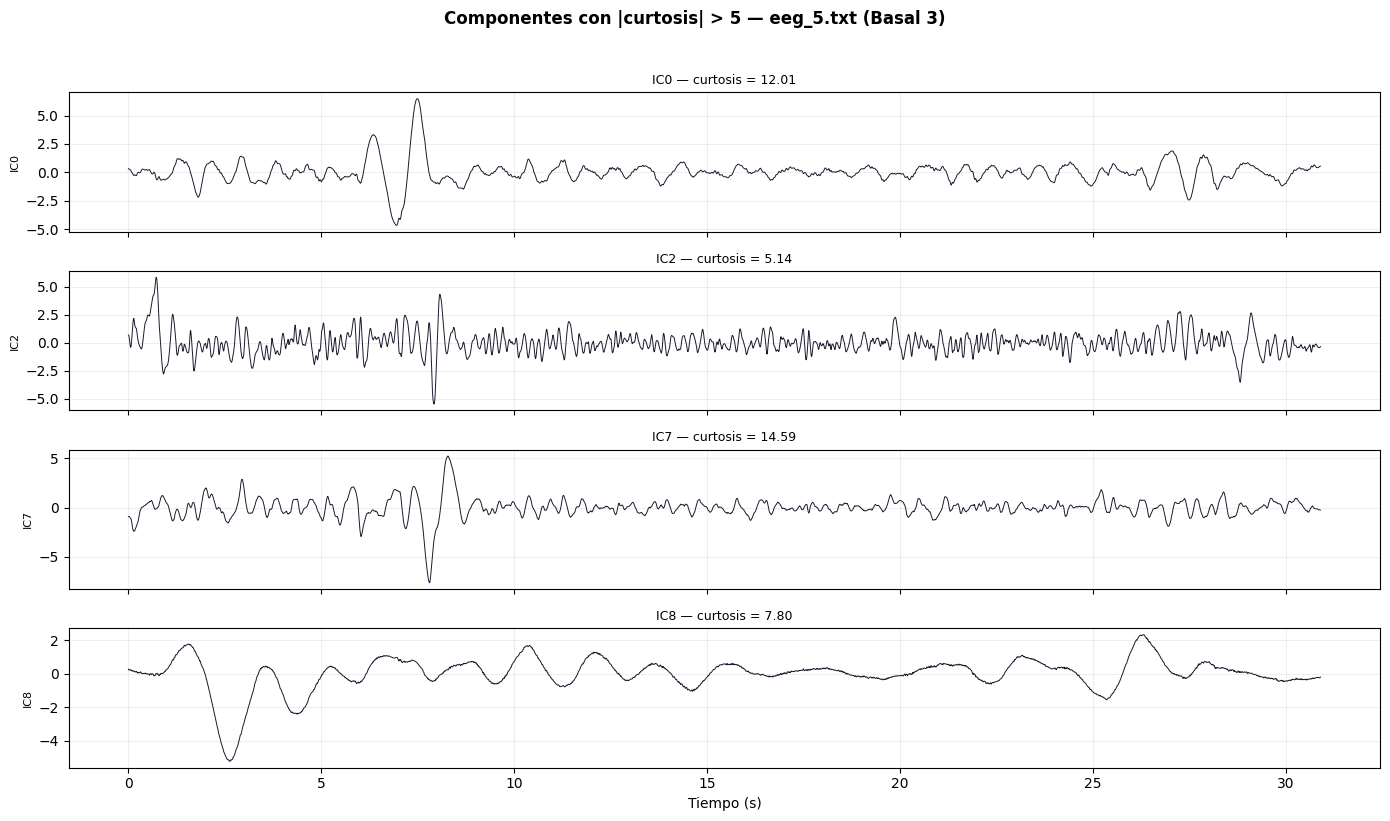


Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:  12.007  ⚠️ candidato a artefacto
  IC1:  -1.443
  IC2:   5.144  ⚠️ candidato a artefacto
  IC3:  -1.452
  IC4:   0.089
  IC5:   2.936
  IC6:   1.322
  IC7:  14.588  ⚠️ candidato a artefacto
  IC8:   7.801  ⚠️ candidato a artefacto

Procesando eeg_6.txt...
Componentes a excluir: [3, 5, 7]


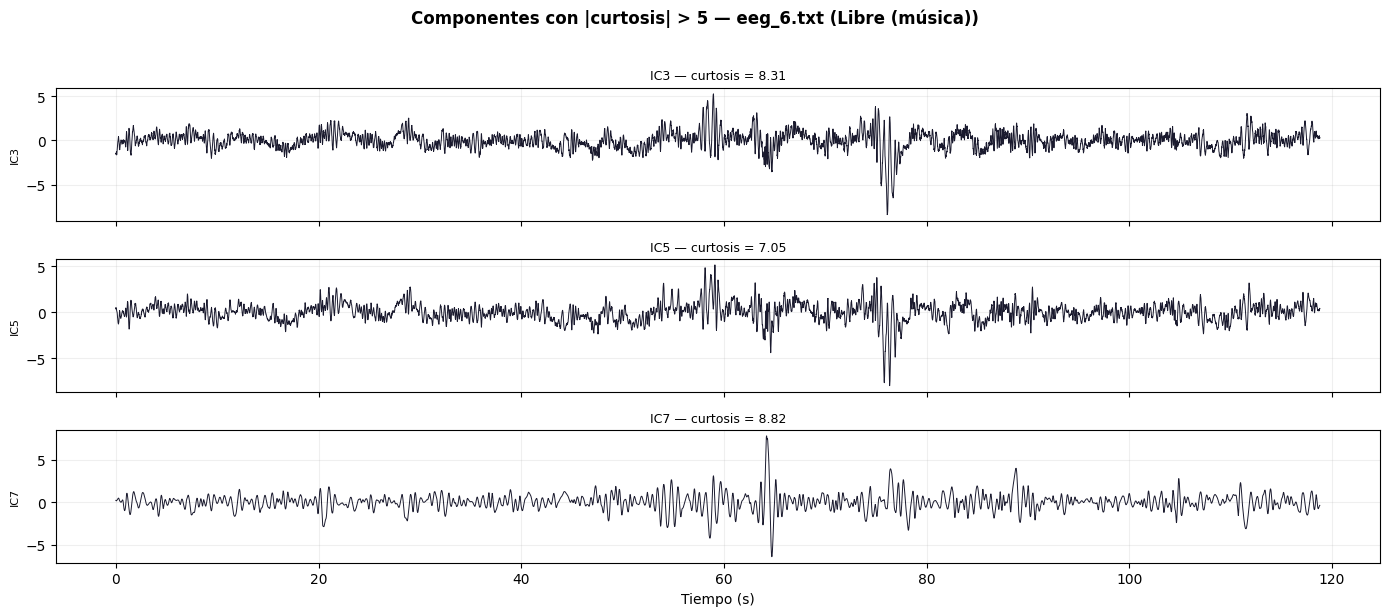


Curtosis por componente (una distribución normal tiene curtosis ≈ 0):
  IC0:   3.173
  IC1:   0.783
  IC2:   0.549
  IC3:   8.306  ⚠️ candidato a artefacto
  IC4:   2.304
  IC5:   7.046  ⚠️ candidato a artefacto
  IC6:   1.304
  IC7:   8.823  ⚠️ candidato a artefacto
  IC8:   1.608

ICA aplicada a todos los archivos.


In [ ]:
for label_ica, d in signals.items():
    print(f"\nProcesando eeg_{label_ica}.txt...")

    sig = d['flt']
    fs = d['fs']
    t = d['t']

    imfs, S, ica = emd_ica_decompose(sig, max_imfs=8)

    kurt = [kurtosis(S[:, i]) for i in range(S.shape[1])]

    # Componentes a excluir (|curtosis| > 5)
    exclude_components = [
        i for i, k in enumerate(kurt)
        if abs(k) > 5
    ]

    print("Componentes a excluir:", exclude_components)

    sig_ica_clean = reconstruct_clean(S, ica, exclude_components)

    signals[label_ica]["ica_clean"] = sig_ica_clean
    signals[label_ica]["ica_kurtosis"] = kurt
    signals[label_ica]["ica_excluded"] = exclude_components

    # ===== Graficar únicamente las componentes con |curtosis| > 5 =====
    if exclude_components:

        fig, axes = plt.subplots(
            len(exclude_components), 1,
            figsize=(14, 2 * len(exclude_components)),
            sharex=True
        )

        if len(exclude_components) == 1:
            axes = [axes]

        for ax, i in zip(axes, exclude_components):
            ax.plot(t, S[:, i], lw=0.7, color="#1a1a2e")
            ax.set_ylabel(f"IC{i}", fontsize=8)
            ax.set_title(f"IC{i} — curtosis = {kurt[i]:.2f}", fontsize=9)
            ax.grid(alpha=0.2)

        axes[-1].set_xlabel("Tiempo (s)")
        fig.suptitle(
            f"Componentes con |curtosis| > 5 — eeg_{label_ica}.txt ({d['label']})",
            y=1.02,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

    else:
        print("No hay componentes con |curtosis| > 5.")

    print("\nCurtosis por componente (una distribución normal tiene curtosis ≈ 0):")
    for i, k in enumerate(kurt):
        flag = "  ⚠️ candidato a artefacto" if abs(k) > 5 else ""
        print(f"  IC{i}: {k:7.3f}{flag}")

print("\nICA aplicada a todos los archivos.")

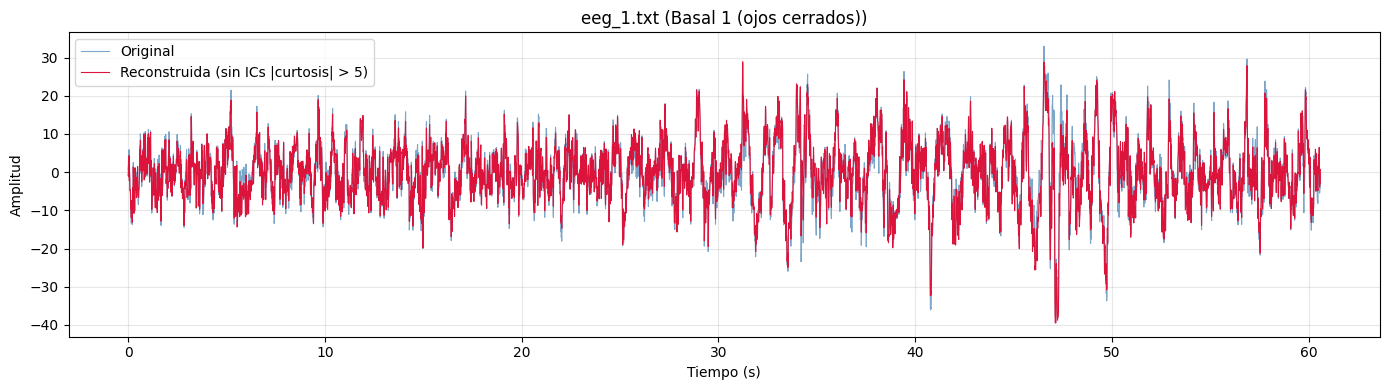

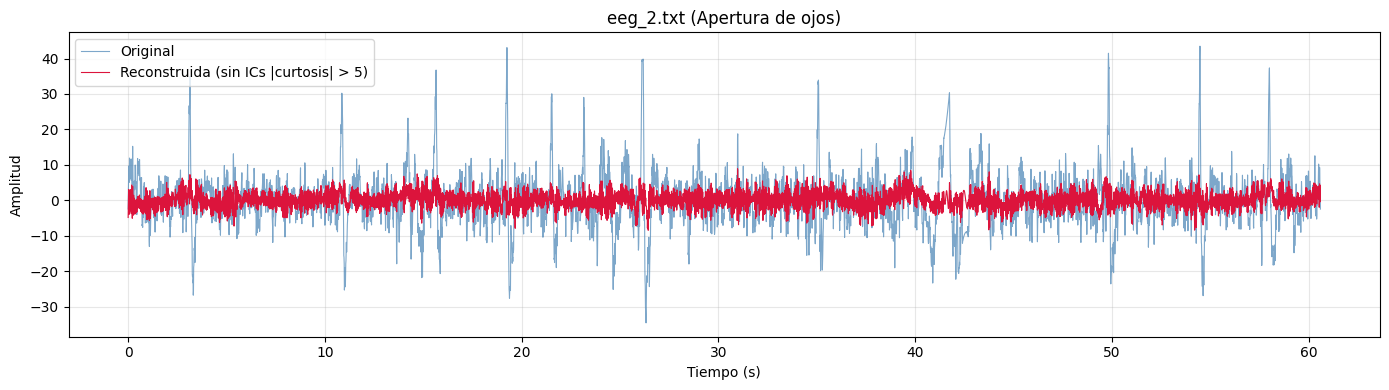

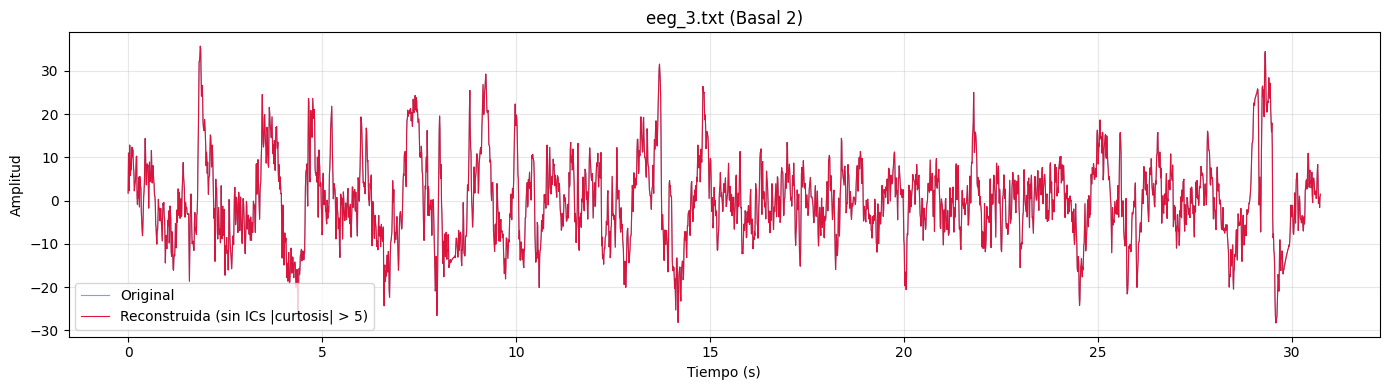

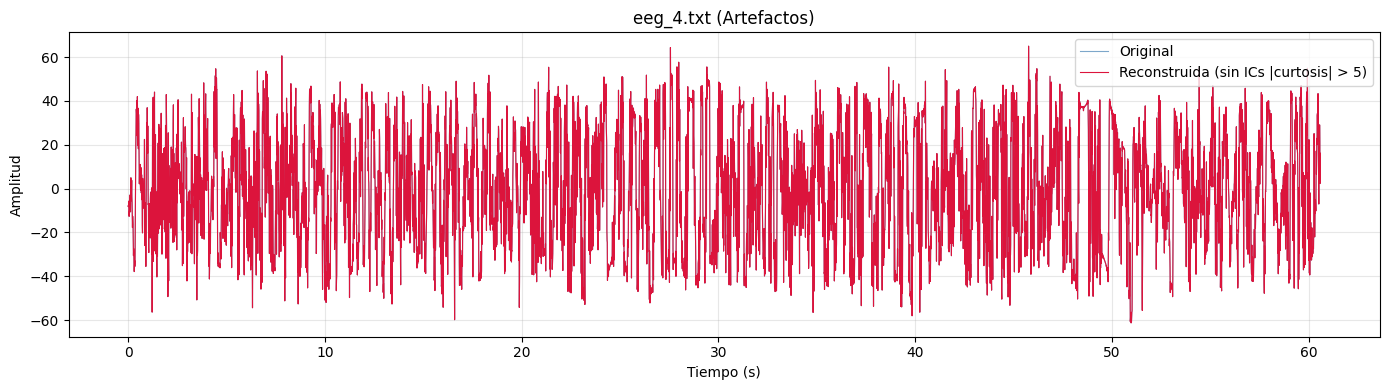

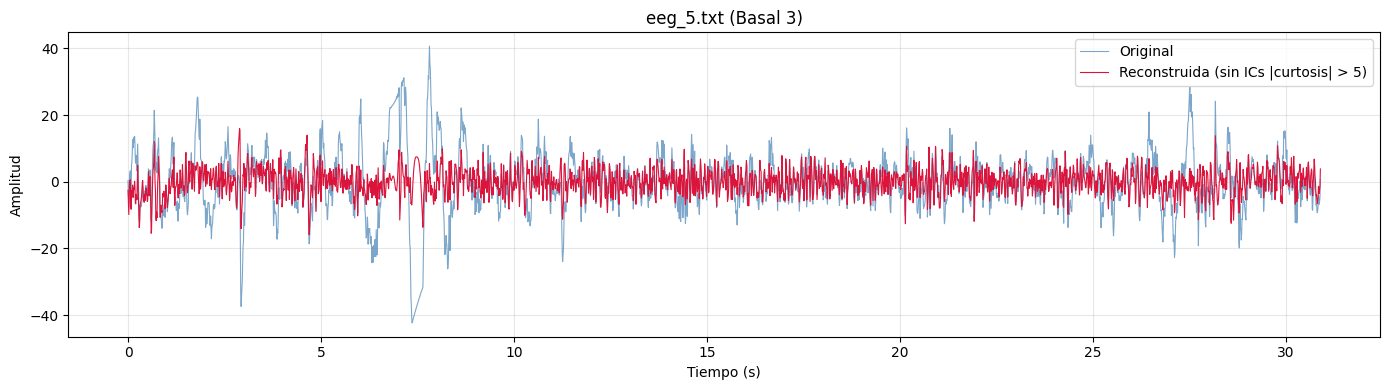

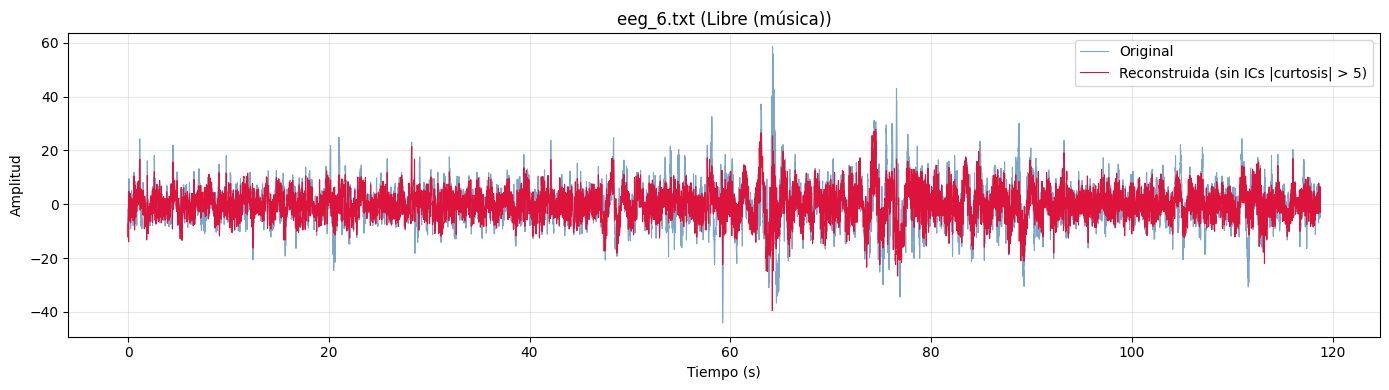

In [ ]:
# Comparación: señal original vs señal reconstruida tras eliminar ICs con |curtosis| > 5

for label_ica, d in signals.items():

    t = d["t"]
    sig_original = d["flt"]
    sig_clean = d["ica_clean"]

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(
        t, sig_original,
        label="Original",
        color="steelblue",
        lw=0.8,
        alpha=0.7
    )

    ax.plot(
        t, sig_clean,
        label="Reconstruida (sin ICs |curtosis| > 5)",
        color="crimson",
        lw=0.8
    )

    ax.set_title(f"eeg_{label_ica}.txt ({d['label']})")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()